# Exploratory Data Analysis
**Project:** Pension Contribution Default Prediction using TabNet & CTGAN-Based Data Augmentation  
**Dataset:** SSNIT Employer Contribution Records — 2022 to 2025  
**Notebook:** 01_eda.ipynb

## 1. Setup

In [16]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

## 2. Data Loading and Initial Inspection

In [17]:
# Loading the dataset
df = pd.read_excel(
    "D:\\MSc. Data Science(UG)\\Semester 2\\Deep Learning & Neural Networks\\Mini Project\\Pension_contribution_data.xlsx",
    sheet_name="main dataset"
)

# Inspecting the dataset
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
print("\nDataset shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   EMPLOYER ID                48000 non-null  object        
 1   REGISTRATION DATE          48000 non-null  datetime64[ns]
 2   EMPLOYER REGION            48000 non-null  object        
 3   REPORTING PERIOD           48000 non-null  int64         
 4   EMPLOYER TYPE              48000 non-null  object        
 5   VALIDATED EMPLOYEE COUNT   48000 non-null  int64         
 6   TOTAL SALARIES VALIDATED   48000 non-null  float64       
 7   EXPECTED CONTRIBUTION      48000 non-null  float64       
 8   CONTRIBUTION PAID          48000 non-null  float64       
 9   PAYMENT STATUS             48000 non-null  object        
 10  PAYMENT DATE               46544 non-null  datetime64[ns]
 11  ARREARS BALANCE            48000 non-null  float64       
 12  CONS

## 3. Data Cleaning

In [18]:
# Filling missing values in 'INSPECTION FLAGS' and 'SANCTION HISTORY' with 'None'
df['INSPECTION FLAGS'] = df['INSPECTION FLAGS'].fillna('None')
df['SANCTION HISTORY'] = df['SANCTION HISTORY'].fillna('None')

# Parsing date columns
df['REGISTRATION DATE'] = pd.to_datetime(df['REGISTRATION DATE'], dayfirst=True, errors='coerce')
df['PAYMENT DATE'] = pd.to_datetime(df['PAYMENT DATE'], dayfirst=True, errors='coerce')

# Verify missing values resolved
print(df[['INSPECTION FLAGS', 'SANCTION HISTORY']].isnull().sum())
print("\nDate columns parsed:")
print(df[['REGISTRATION DATE', 'PAYMENT DATE']].dtypes)

INSPECTION FLAGS    0
SANCTION HISTORY    0
dtype: int64

Date columns parsed:
REGISTRATION DATE    datetime64[ns]
PAYMENT DATE         datetime64[ns]
dtype: object


## 4. Default Label Creation

In [19]:
# Chronological sorting of the dataset for each employer
df = df.sort_values(by=['EMPLOYER ID', 'REPORTING PERIOD'])

# Calculating the rolling 3-month contribution ratio per employer
rolling_paid     = df.groupby('EMPLOYER ID')['CONTRIBUTION PAID'].rolling(window=3, min_periods=1).sum().reset_index(level=0, drop=True)
rolling_expected = df.groupby('EMPLOYER ID')['EXPECTED CONTRIBUTION'].rolling(window=3, min_periods=1).sum().reset_index(level=0, drop=True)

# Avoid division by zero
df['ROLLING_3MO_RATIO'] = rolling_paid / rolling_expected.replace(0, 1)

# Creating the two default condition flags
df['FLAG_LOW_RATIO']       = (df['ROLLING_3MO_RATIO'] < 0.80).astype(int)
df['FLAG_CONSECUTIVE_MISS'] = (df['CONSECUTIVE MONTHS MISSED'] >= 2).astype(int)

# Default the month if either flag is 1
df['IS_DEFAULT_MONTH'] = df[['FLAG_LOW_RATIO', 'FLAG_CONSECUTIVE_MISS']].max(axis=1)

# Compress to employer-level: 1 default month implies a 1 overall for the employer
employer_labels = df.groupby('EMPLOYER ID')['IS_DEFAULT_MONTH'].max().reset_index()
employer_labels.rename(columns={'IS_DEFAULT_MONTH': 'DEFAULT_LABEL'}, inplace=True)

print("Default label distribution:")
print(employer_labels['DEFAULT_LABEL'].value_counts())
print(f"\nDefault rate: {employer_labels['DEFAULT_LABEL'].mean():.1%}")

Default label distribution:
DEFAULT_LABEL
0    747
1    253
Name: count, dtype: int64

Default rate: 25.3%


## 5. Feature Engineering

In [20]:
# ── Helper: payment amount trend (slope of linear regression over time) ──
def compute_trend(series):
    s = series.fillna(0).values
    if len(s) < 2:
        return 0.0
    return np.polyfit(range(len(s)), s, 1)[0]

# ── Aggregating behavioural features per employer ──
behavioral_features = df.groupby('EMPLOYER ID').agg(
    TOTAL_ARREARS          = ('ARREARS BALANCE',          'sum'),
    MAX_CONSECUTIVE_MISSED = ('CONSECUTIVE MONTHS MISSED', 'max'),
    AVG_CONTRIBUTION_RATIO = ('ROLLING_3MO_RATIO',         'mean'),
    MONTHS_WITH_SANCTIONS  = ('SANCTION HISTORY',          lambda x: (x != 'None').sum()),
    PAYMENT_RATE           = ('PAYMENT STATUS',            lambda x: (x == 'PAID').sum() / len(x)),
    AMOUNT_CV              = ('CONTRIBUTION PAID',         lambda x: x.std() / x.mean() if x.mean() != 0 else 0),
    AMOUNT_TREND           = ('CONTRIBUTION PAID',         compute_trend)
).reset_index()

# ── Employer tenure: years since registration as at Dec 2025 ──
reference_date = pd.Timestamp('2025-12-31')
tenure = df.groupby('EMPLOYER ID')['REGISTRATION DATE'].first().reset_index()
tenure['EMPLOYER_TENURE'] = (reference_date - tenure['REGISTRATION DATE']).dt.days / 365.25
behavioral_features = pd.merge(behavioral_features, tenure[['EMPLOYER ID', 'EMPLOYER_TENURE']], on='EMPLOYER ID')

# ── Payment delay: avg days from period end to payment date ──
df['PERIOD_END_DATE'] = pd.to_datetime(
    df['REPORTING PERIOD'].astype(str).str[:4] + '-' +
    df['REPORTING PERIOD'].astype(str).str[4:] + '-01',
    errors='coerce'
) + pd.offsets.MonthEnd(0)

df['PAYMENT_DELAY_DAYS'] = (df['PAYMENT DATE'] - df['PERIOD_END_DATE']).dt.days

delay = df.groupby('EMPLOYER ID')['PAYMENT_DELAY_DAYS'].mean().reset_index()
delay.columns = ['EMPLOYER ID', 'AVG_PAYMENT_DELAY']
# Treat unpaid months (NaT) as maximum observed delay + 30
max_delay = delay['AVG_PAYMENT_DELAY'].max()
delay['AVG_PAYMENT_DELAY'] = delay['AVG_PAYMENT_DELAY'].fillna(max_delay + 30)
behavioral_features = pd.merge(behavioral_features, delay, on='EMPLOYER ID')

# ── Merging with default labels ──
final_features = pd.merge(behavioral_features, employer_labels, on='EMPLOYER ID')

print("Feature matrix shape:", final_features.shape)
print("\nColumns:", list(final_features.columns))
print("\nFirst few rows:")
final_features.head()

Feature matrix shape: (1000, 11)

Columns: ['EMPLOYER ID', 'TOTAL_ARREARS', 'MAX_CONSECUTIVE_MISSED', 'AVG_CONTRIBUTION_RATIO', 'MONTHS_WITH_SANCTIONS', 'PAYMENT_RATE', 'AMOUNT_CV', 'AMOUNT_TREND', 'EMPLOYER_TENURE', 'AVG_PAYMENT_DELAY', 'DEFAULT_LABEL']

First few rows:


,EMPLOYER ID,TOTAL_ARREARS,MAX_CONSECUTIVE_MISSED,AVG_CONTRIBUTION_RATIO,MONTHS_WITH_SANCTIONS,PAYMENT_RATE,AMOUNT_CV,AMOUNT_TREND,EMPLOYER_TENURE,AVG_PAYMENT_DELAY,DEFAULT_LABEL
0,XXXXX0010_20190102,122179.860000,0,1.000000,48,1.000000,0.625885,-7.812883,6.995209,220.354167,0
1,XXXXX0011_20070122,-495630.249312,0,1.000000,48,1.000000,0.218855,10910.506218,18.940452,11.979167,0
2,XXXXX0011_20180102,41715.000000,0,0.993056,48,0.979167,0.400094,9.602556,7.994524,72.319149,1
3,XXXXX0025_20180103,631.530000,0,1.000000,48,1.000000,0.310405,5.000202,7.991786,20.062500,0
4,XXXXX0027_20220105,2214.000000,0,1.000000,48,1.000000,0.091871,0.422058,3.986311,35.145833,0


## 6. Descriptive Statistics

In [21]:
# Summary statistics of the full feature matrix
print("Descriptive statistics — all employers:")
final_features.drop('EMPLOYER ID', axis=1).describe().round(4)

Descriptive statistics — all employers:


,TOTAL_ARREARS,MAX_CONSECUTIVE_MISSED,AVG_CONTRIBUTION_RATIO,MONTHS_WITH_SANCTIONS,PAYMENT_RATE,AMOUNT_CV,AMOUNT_TREND,EMPLOYER_TENURE,AVG_PAYMENT_DELAY,DEFAULT_LABEL
count,1.000000e+03,1000.0,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,3.827762e+04,0.0,0.9710,43.6800,0.9622,0.3496,89.6432,12.2591,50.4071,0.2530
std,1.061700e+06,0.0,0.0882,13.7436,0.0985,0.2555,637.2772,8.0180,77.0328,0.4349
min,-1.813951e+07,0.0,0.3272,0.0000,0.2917,0.0000,-559.5864,0.7064,-369.4545,0.0000
25%,-9.333000e+01,0.0,0.9931,48.0000,0.9792,0.1849,0.1091,6.2471,12.2812,0.0000
50%,4.051425e+03,0.0,1.0000,48.0000,1.0000,0.2969,3.8916,9.3101,22.1095,0.0000
75%,2.746303e+04,0.0,1.0000,48.0000,1.0000,0.4407,19.5467,16.6112,59.8938,1.0000
max,2.615921e+07,0.0,1.0229,48.0000,1.0000,2.1111,12321.7154,34.5298,647.6042,1.0000


In [22]:
# Summary statistics split by default status
print("Descriptive statistics — by default label:")
final_features.drop('EMPLOYER ID', axis=1).groupby('DEFAULT_LABEL').describe().T

Descriptive statistics — by default label:


DEFAULT_LABEL                       0             1
TOTAL_ARREARS     count  7.470000e+02  2.530000e+02
                  mean  -3.077292e+04  2.421541e+05
                  std    7.148031e+05  1.702983e+06
                  min   -1.813951e+07 -1.808524e+05
                  25%   -2.271370e+03  8.938770e+03
...                               ...           ...
AVG_PAYMENT_DELAY min   -4.641667e+01 -3.694545e+02
                  25%    1.123958e+01  3.422222e+01
                  50%    1.635417e+01  6.602174e+01
                  75%    3.747917e+01  1.280000e+02
                  max    6.476042e+02  6.420444e+02

[72 rows x 2 columns]

## 7. Outlier Treatment (Winsorisation)

In [23]:
# Capping continuous features at the 99th percentile
continuous_cols = ['TOTAL_ARREARS', 'AVG_CONTRIBUTION_RATIO', 'AMOUNT_CV', 'AVG_PAYMENT_DELAY']

for col in continuous_cols:
    upper_limit = final_features[col].quantile(0.99)
    final_features[col] = np.where(final_features[col] > upper_limit, upper_limit, final_features[col])

# Cap AVG_CONTRIBUTION_RATIO at 1.0 (overpayment beyond 100% is not informative)
final_features['AVG_CONTRIBUTION_RATIO'] = np.where(
    final_features['AVG_CONTRIBUTION_RATIO'] > 1.0, 1.0, final_features['AVG_CONTRIBUTION_RATIO']
)

print("Outlier capping complete.")
print(final_features[continuous_cols].describe().round(4))

Outlier capping complete.
       TOTAL_ARREARS  AVG_CONTRIBUTION_RATIO  AMOUNT_CV  AVG_PAYMENT_DELAY
count   1.000000e+03               1000.0000  1000.0000          1000.0000
mean    5.238208e+02                  0.9709     0.3476            49.3821
std     6.233116e+05                  0.0881     0.2445            70.7216
min    -1.813951e+07                  0.3272     0.0000          -369.4545
25%    -9.333000e+01                  0.9931     0.1849            12.2812
50%     4.051425e+03                  1.0000     0.2969            22.1095
75%     2.746303e+04                  1.0000     0.4407            59.8938
max     1.066478e+06                  1.0000     1.4345           412.8754


## 8. Export Feature Matrix


In [24]:
export_path = "D:/MSc. Data Science(UG)/Semester 2/Deep Learning & Neural Networks/Mini Project/features.csv"
final_features.to_csv(export_path, index=False)
print(f"Data successfully exported to '{export_path}'")

Data successfully exported to 'D:/MSc. Data Science(UG)/Semester 2/Deep Learning & Neural Networks/Mini Project/features.csv'


## 9. Visualisations
### 9.1 Class Balance

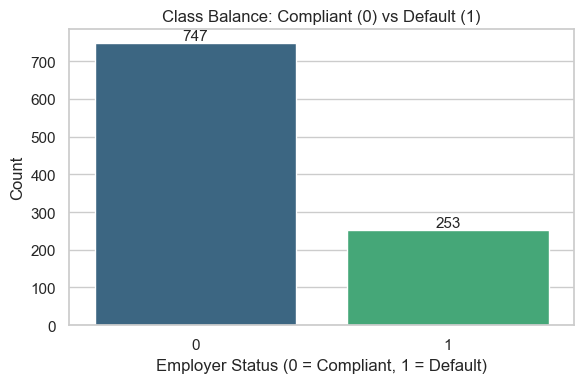

In [31]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=final_features, x='DEFAULT_LABEL', hue='DEFAULT_LABEL', palette='viridis', legend=False)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Class Balance: Compliant (0) vs Default (1)')
plt.xlabel('Employer Status (0 = Compliant, 1 = Default)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 9.2 Correlation Heatmap

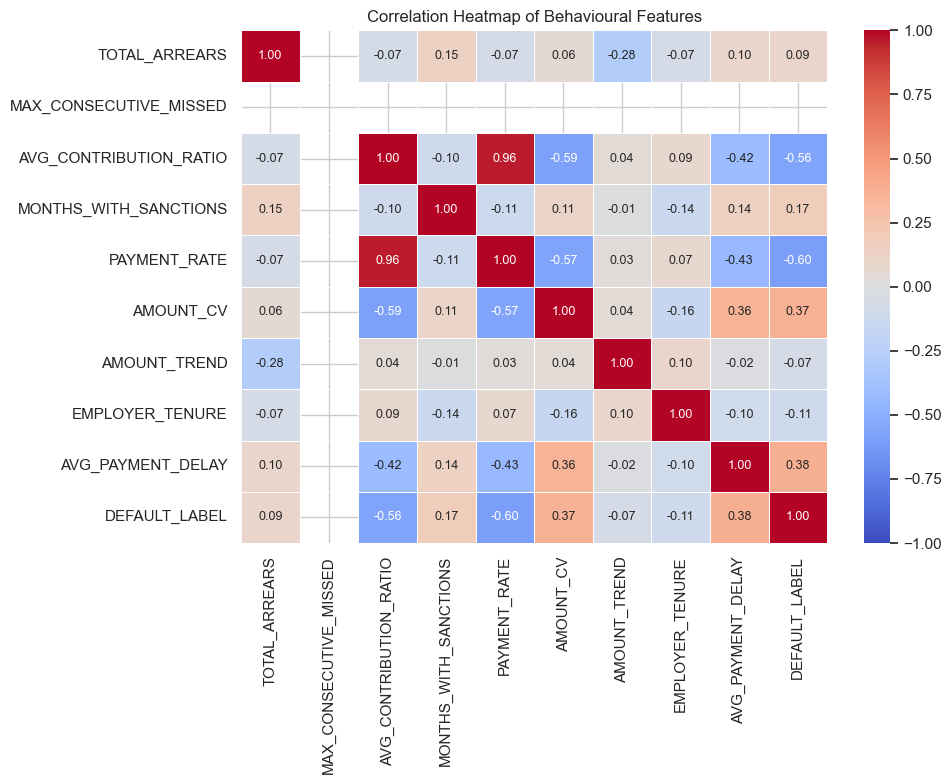

In [26]:
plt.figure(figsize=(10, 8))
correlation_matrix = final_features.drop('EMPLOYER ID', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap of Behavioural Features')
plt.tight_layout()
plt.show()

### 9.3 Feature Distributions by Default Status

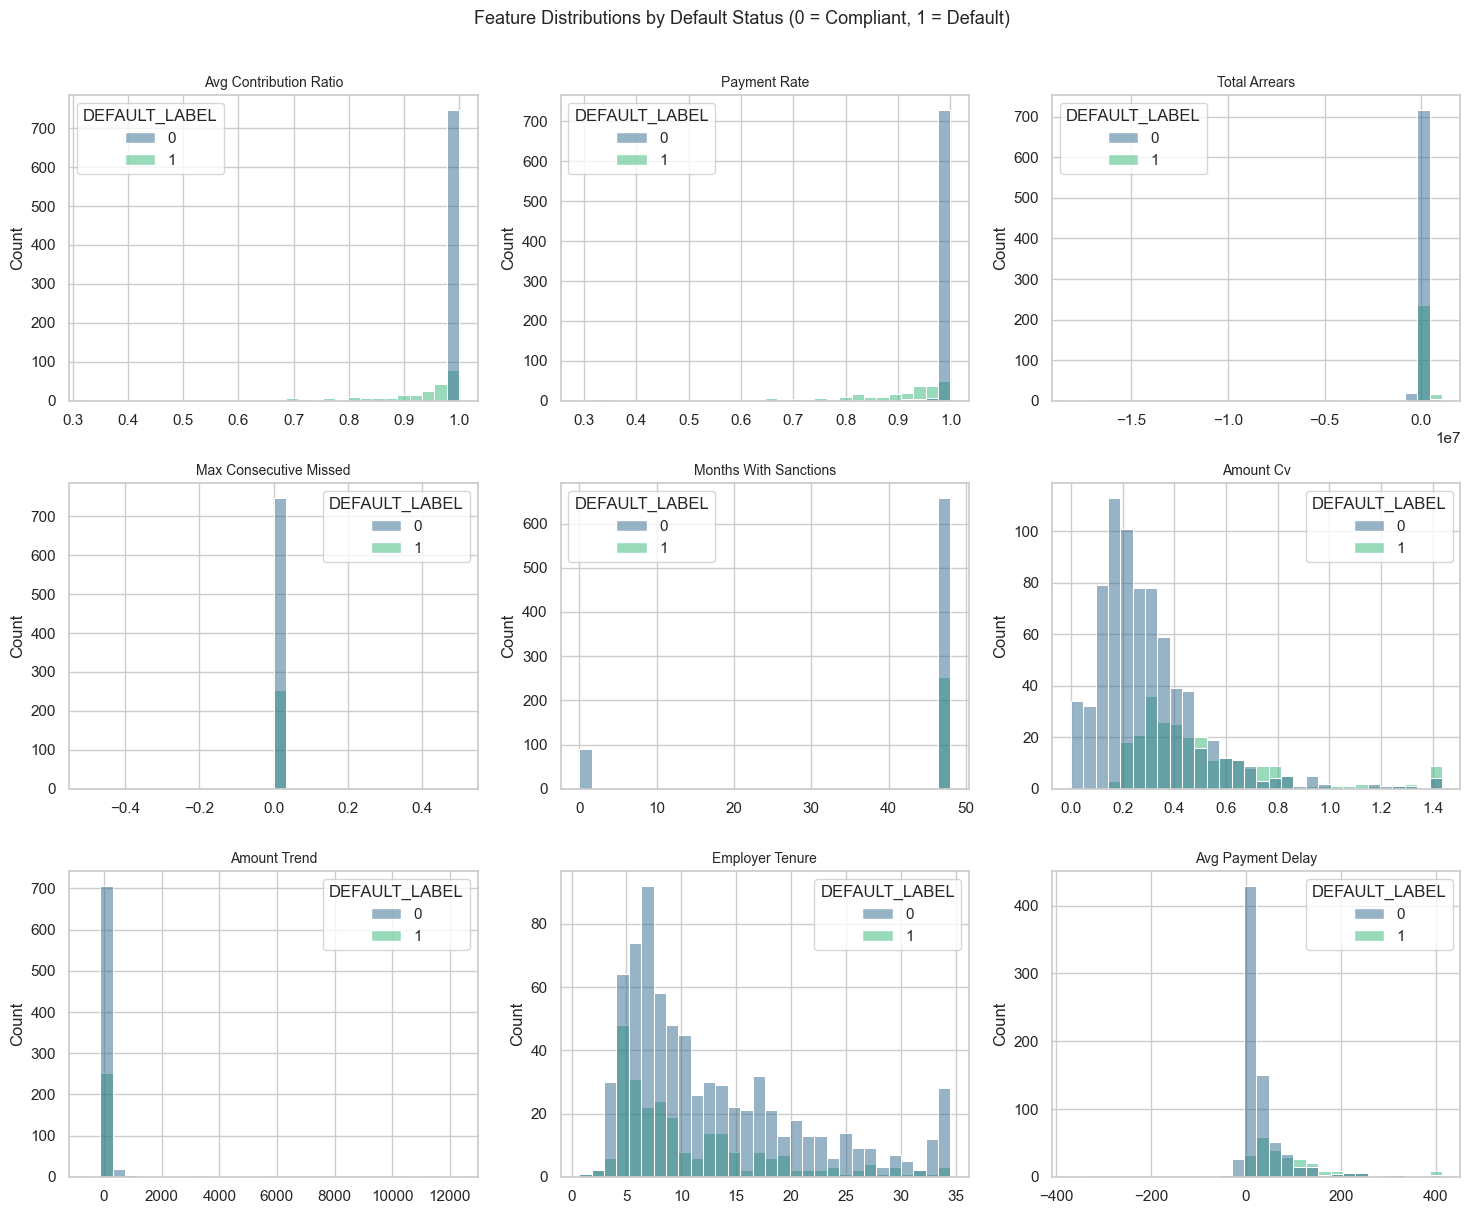

In [28]:
feature_cols = [
    'AVG_CONTRIBUTION_RATIO', 'PAYMENT_RATE', 'TOTAL_ARREARS',
    'MAX_CONSECUTIVE_MISSED', 'MONTHS_WITH_SANCTIONS', 'AMOUNT_CV',
    'AMOUNT_TREND', 'EMPLOYER_TENURE', 'AVG_PAYMENT_DELAY'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(
        data=final_features, x=col, hue='DEFAULT_LABEL',
        palette='viridis', bins=30, ax=axes[i]
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions by Default Status (0 = Compliant, 1 = Default)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 9.4 Box Plots — Feature Separation by Default Label

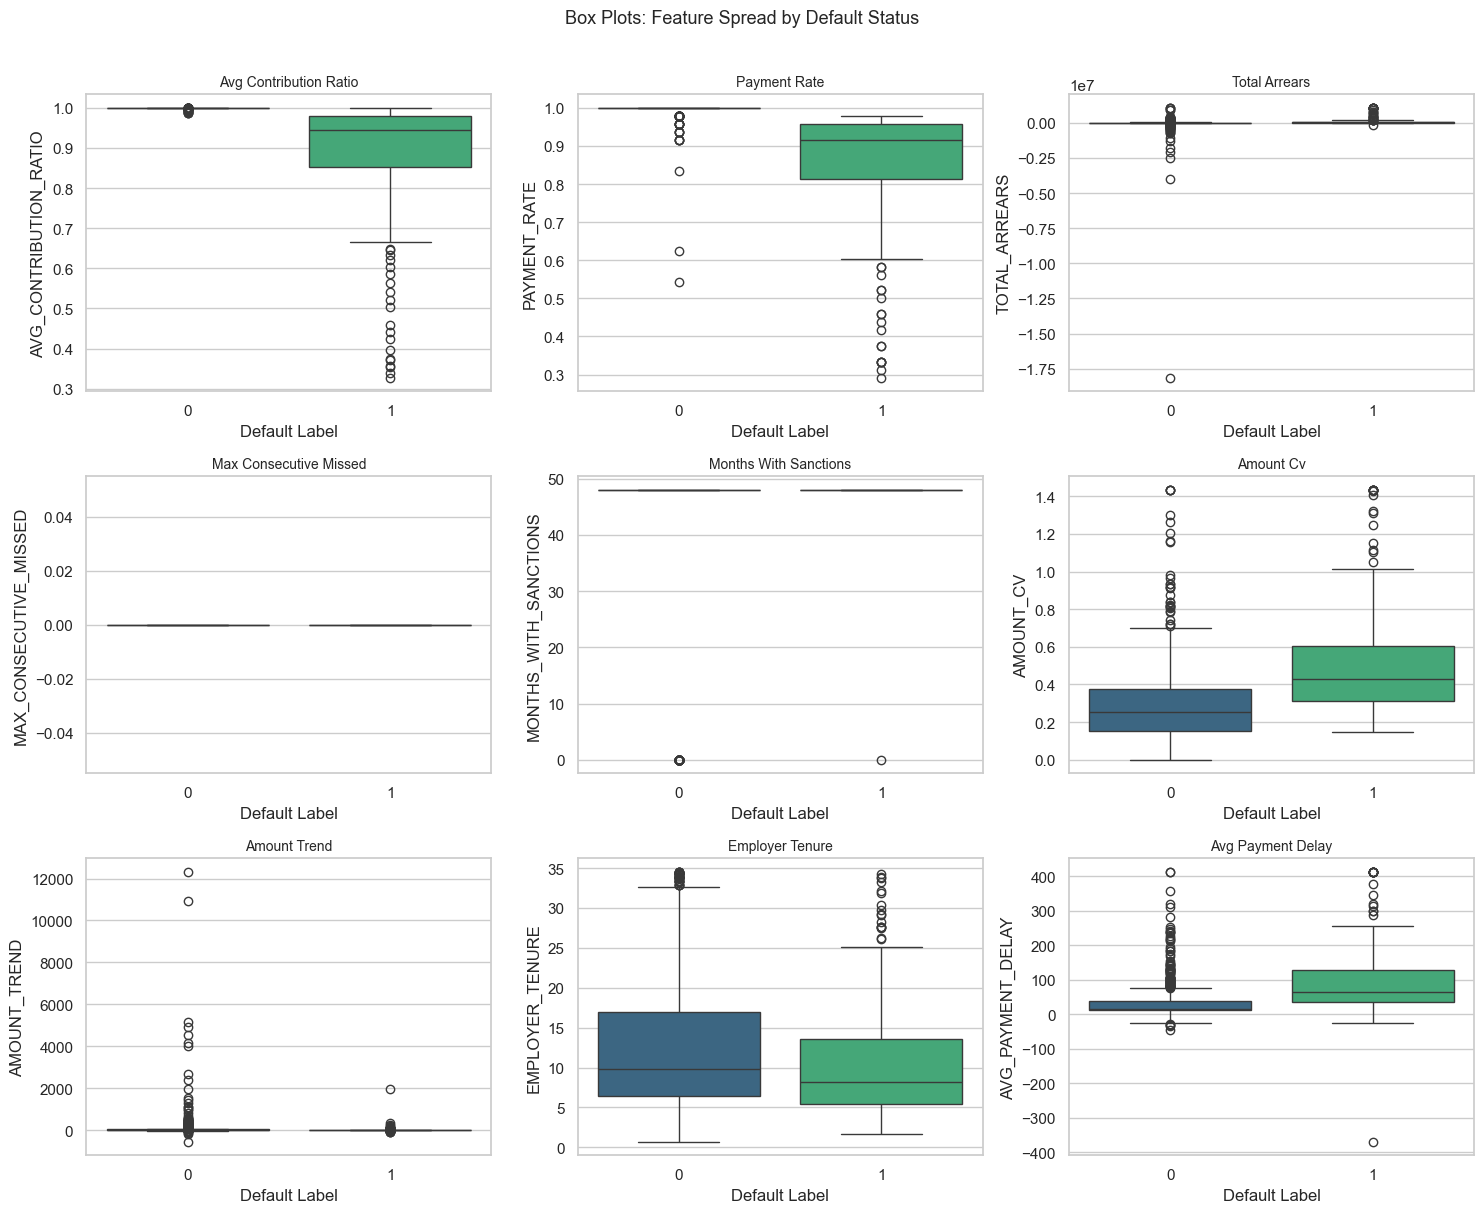

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(
        data=final_features, x='DEFAULT_LABEL', y=col,
        hue='DEFAULT_LABEL', palette='viridis', legend=False, ax=axes[i]
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_xlabel('Default Label')

plt.suptitle('Box Plots: Feature Spread by Default Status', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 9.5 Default Rate by Employer Region

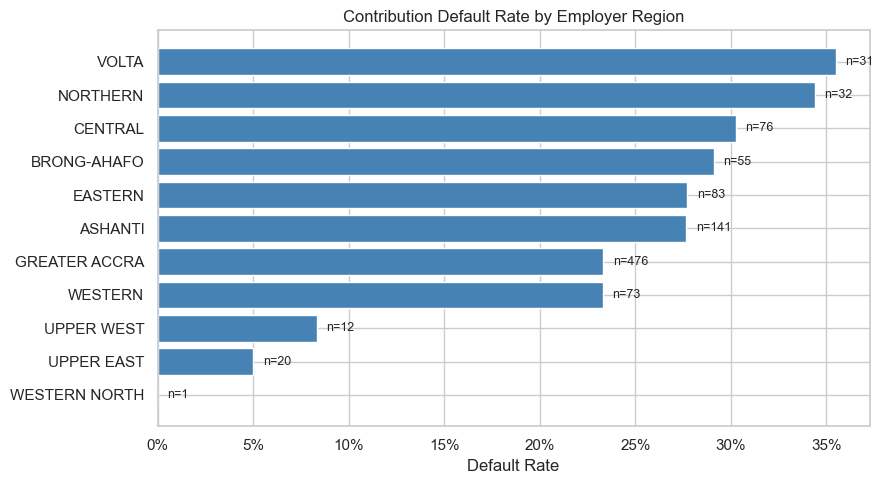

In [32]:
# Bring in EMPLOYER REGION from the raw data
region_df = df.groupby('EMPLOYER ID')['EMPLOYER REGION'].first().reset_index()
region_merged = pd.merge(final_features[['EMPLOYER ID', 'DEFAULT_LABEL']], region_df, on='EMPLOYER ID')

region_default = (
    region_merged.groupby('EMPLOYER REGION')['DEFAULT_LABEL']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Default Rate', 'count': 'Employer Count'})
    .sort_values('Default Rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(region_default.index, region_default['Default Rate'], color='steelblue')
for bar, count in zip(bars, region_default['Employer Count']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'n={count}', va='center', fontsize=9)
ax.set_xlabel('Default Rate')
ax.set_title('Contribution Default Rate by Employer Region')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

### 9.6 Monthly Default Rate Trend (2022–2025)

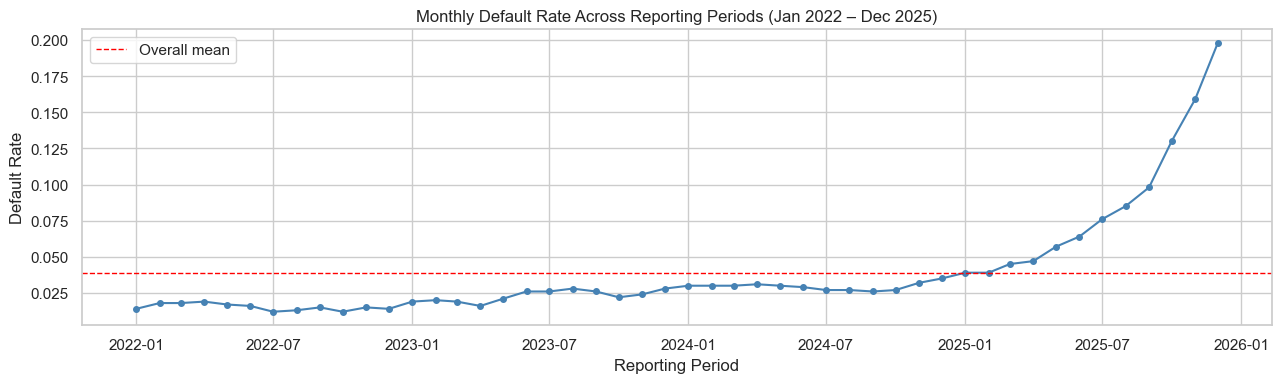

In [33]:
monthly_default = (
    df.groupby('REPORTING PERIOD')['IS_DEFAULT_MONTH']
    .mean()
    .reset_index()
    .rename(columns={'IS_DEFAULT_MONTH': 'Default Rate'})
)

# Convert REPORTING PERIOD to readable date string
monthly_default['Period'] = pd.to_datetime(
    monthly_default['REPORTING PERIOD'].astype(str), format='%Y%m'
)

plt.figure(figsize=(13, 4))
plt.plot(monthly_default['Period'], monthly_default['Default Rate'],
         marker='o', markersize=4, linewidth=1.5, color='steelblue')
plt.axhline(monthly_default['Default Rate'].mean(), color='red',
            linestyle='--', linewidth=1, label='Overall mean')
plt.title('Monthly Default Rate Across Reporting Periods (Jan 2022 – Dec 2025)')
plt.xlabel('Reporting Period')
plt.ylabel('Default Rate')
plt.yaxis_set_major_formatter = plt.FuncFormatter(lambda x, _: f'{x:.0%}')
plt.legend()
plt.tight_layout()
plt.show()

### 9.7 Sanctions and Inspection Flags Distribution

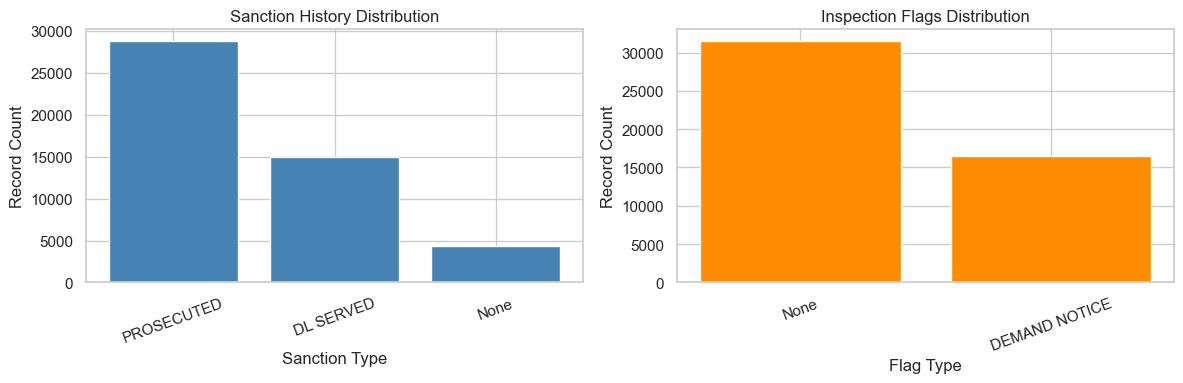

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sanction history
sanction_counts = df['SANCTION HISTORY'].value_counts()
axes[0].bar(sanction_counts.index, sanction_counts.values, color='steelblue')
axes[0].set_title('Sanction History Distribution')
axes[0].set_xlabel('Sanction Type')
axes[0].set_ylabel('Record Count')
axes[0].tick_params(axis='x', rotation=20)

# Inspection flags
flag_counts = df['INSPECTION FLAGS'].value_counts()
axes[1].bar(flag_counts.index, flag_counts.values, color='darkorange')
axes[1].set_title('Inspection Flags Distribution')
axes[1].set_xlabel('Flag Type')
axes[1].set_ylabel('Record Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()